# How do deliveries change during high-demand periods?

This notebook studies **lunchtime** and **dinnertime** demand in the Washington, DC food-delivery simulation.

It answers four parts:

1. When are the high-demand periods?
2. How much does delivery time increase during lunch and dinner?
3. Does the effect depend on fleet size and assignment strategy?
4. Does congestion continue after the demand peak ends?

## Imports

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## Load the data

In [ ]:
# Load orders data
orders_path = Path("../data/clean/dc_orders_sim.csv")
orders = pd.read_csv(orders_path)

# Load delivery data
deliveries_path = Path("../data/clean/dc_delivery_events.csv")
deliveries = pd.read_csv(deliveries_path)

# Show data
print(f"Loaded {len(orders):,} orders")
print(f"Loaded {len(deliveries):,} delivery-event rows")
orders.head()

Loaded 15,188 orders
Loaded 60,752 delivery-event rows


,order_id,strategy,fleet,hour,pickup_node,dropoff_node,drive_time_s,drive_dist_m,t_order_s,t_assign_s,t_pickup_s,t_deliver_s,click_to_door_min,courier_id
0,1,nac,200,0,49743231,646216520,1133.4,14133.0,81.8,81.8,681.8,1935.2,30.89,179
1,2,nac,200,0,774340109,49779846,349.3,3917.0,110.9,110.9,710.9,1180.2,17.82,145
2,3,nac,200,0,49793773,49839482,832.2,9764.0,149.8,149.8,749.8,1702.0,25.87,59
3,4,nac,200,0,49745240,49745636,154.5,1763.0,209.9,209.9,809.9,1084.4,14.57,113
4,5,nac,200,0,4807605970,49800282,346.0,3862.0,304.0,304.0,904.0,1370.0,17.77,66


In [8]:
deliveries.head()

,order_id,strategy,fleet,hour,pickup_node,dropoff_node,drive_time_s,drive_dist_m,t_order_s,t_assign_s,t_pickup_s,t_deliver_s,click_to_door_min,courier_id
0,1,nac,200,0,49743231,646216520,1133.4,14133.0,81.8,81.8,681.8,1935.2,30.89,179
1,2,nac,200,0,774340109,49779846,349.3,3917.0,110.9,110.9,710.9,1180.2,17.82,145
2,3,nac,200,0,49793773,49839482,832.2,9764.0,149.8,149.8,749.8,1702.0,25.87,59
3,4,nac,200,0,49745240,49745636,154.5,1763.0,209.9,209.9,809.9,1084.4,14.57,113
4,5,nac,200,0,4807605970,49800282,346.0,3862.0,304.0,304.0,904.0,1370.0,17.77,66


## Find the high-demand hours

,hour,order_count
19,19,2279
18,18,2052
20,20,2010
12,12,1684
11,11,1571
13,13,1555
17,17,536
21,21,416
14,14,403
10,10,376


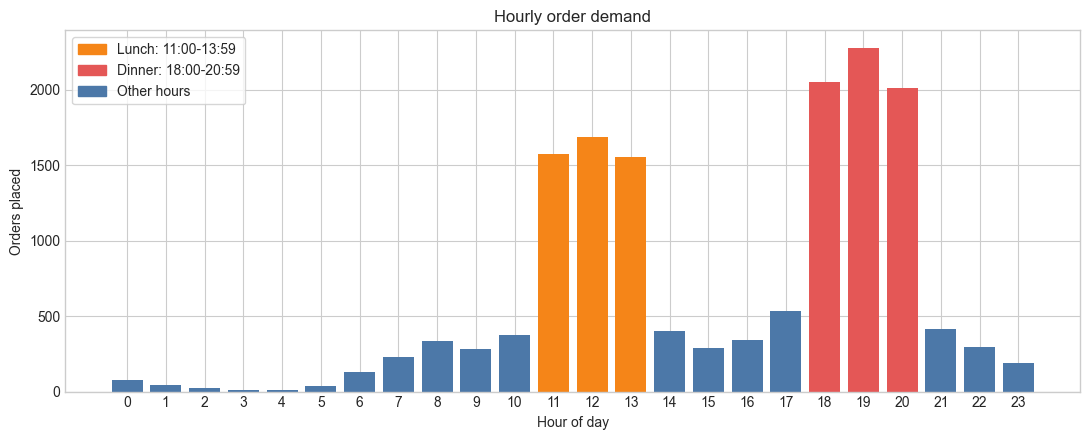

In [9]:
hourly_demand = (
    orders.groupby("hour")
    .agg(order_count=("order_id", "size"))
    .reindex(range(24), fill_value=0)
    .reset_index()
)

display(hourly_demand.sort_values("order_count", ascending=False).head(10))

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = [
    "#F58518" if 11 <= hour <= 13 else
    "#E45756" if 18 <= hour <= 20 else
    "#4C78A8"
    for hour in hourly_demand["hour"]
]

ax.bar(hourly_demand["hour"], hourly_demand["order_count"], color=colors)
ax.set_title("Hourly order demand")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Orders placed")
ax.set_xticks(range(24))
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color="#F58518", label="Lunch: 11:00-13:59"),
        plt.Rectangle((0, 0), 1, 1, color="#E45756", label="Dinner: 18:00-20:59"),
        plt.Rectangle((0, 0), 1, 1, color="#4C78A8", label="Other hours"),
    ],
    frameon=True,
)
plt.tight_layout()
plt.show()

The order counts show two clear surges. Therefore, this notebook defines:

- **Lunch peak:** 11:00-13:59 (`hour` 11, 12, and 13)
- **Dinner peak:** 18:00-20:59 (`hour` 18, 19, and 20)

The hours immediately after each peak are kept separate so we can check whether a delivery backlog continues after demand falls.

## Summarize demand by time period

In [10]:
period_order = [
    "Overnight/morning (0-10)",
    "Lunch peak (11-13)",
    "Afternoon/recovery (14-17)",
    "Dinner peak (18-20)",
    "Late evening/recovery (21-23)",
]


def assign_period(hour):
    if 11 <= hour <= 13:
        return "Lunch peak (11-13)"
    if 14 <= hour <= 17:
        return "Afternoon/recovery (14-17)"
    if 18 <= hour <= 20:
        return "Dinner peak (18-20)"
    if 21 <= hour <= 23:
        return "Late evening/recovery (21-23)"
    return "Overnight/morning (0-10)"


orders["period"] = pd.Categorical(
    orders["hour"].map(assign_period),
    categories=period_order,
    ordered=True,
)
deliveries["period"] = pd.Categorical(
    deliveries["hour"].map(assign_period),
    categories=period_order,
    ordered=True,
)

demand_summary = (
    orders.groupby("period", observed=False)
    .agg(
        orders=("order_id", "size"),
        hours=("hour", "nunique"),
    )
)
demand_summary["average_orders_per_hour"] = (
    demand_summary["orders"] / demand_summary["hours"]
)
demand_summary["share_of_all_orders_pct"] = (
    100 * demand_summary["orders"] / len(orders)
)

display(demand_summary.round(2))

,orders,hours,average_orders_per_hour,share_of_all_orders_pct
period,,,,
Overnight/morning (0-10),1556,11,141.45,10.24
Lunch peak (11-13),4810,3,1603.33,31.67
Afternoon/recovery (14-17),1575,4,393.75,10.37
Dinner peak (18-20),6341,3,2113.67,41.75
Late evening/recovery (21-23),906,3,302.00,5.97


Lunch contains **4,810 orders** and dinner contains **6,341 orders**. Together they account for **73.42%** of all orders even though they cover only 6 of the 24 hours.

Dinner averages **2,113.67 orders per hour**, which is **31.84% higher** than lunch's 1,603.33 orders per hour.

## Plot hourly delivery performance

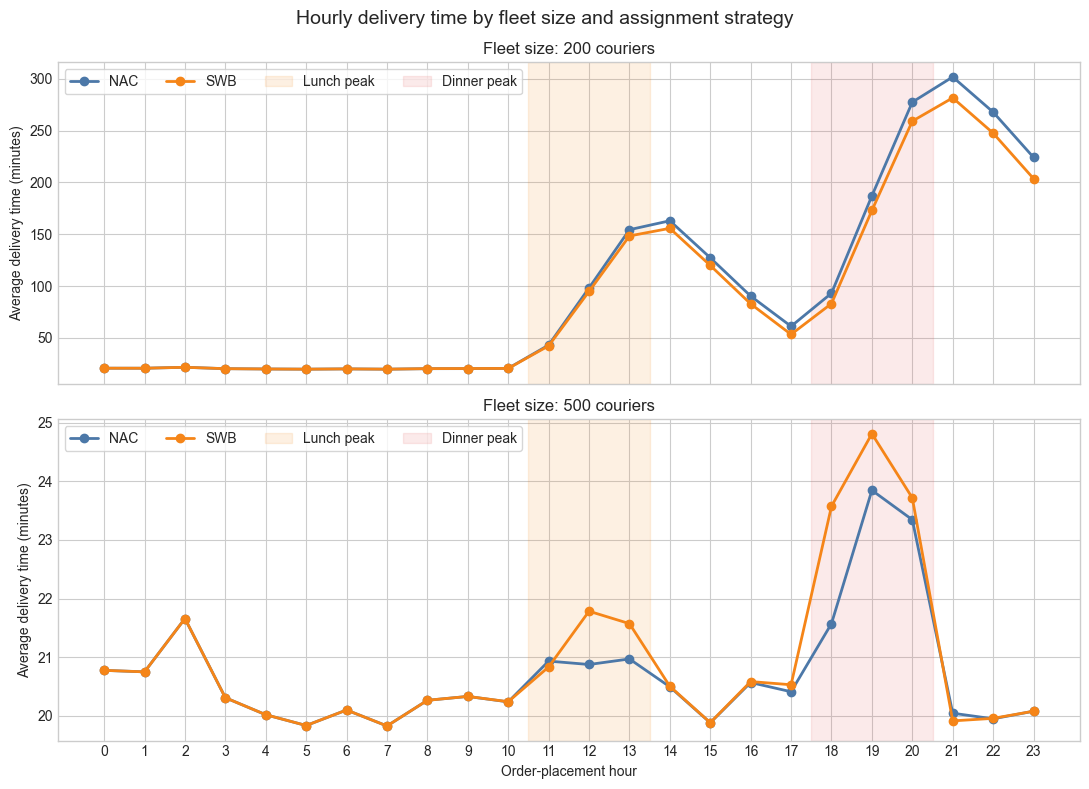

In [12]:
hourly_delivery = (
    deliveries.groupby(["hour", "fleet", "strategy"], as_index=False)
    .agg(mean_delivery_min=("click_to_door_min", "mean"))
)

strategy_colors = {"nac": "#4C78A8", "swb": "#F58518"}
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for ax, fleet_size in zip(axes, sorted(deliveries["fleet"].unique())):
    fleet_data = hourly_delivery[hourly_delivery["fleet"] == fleet_size]

    for strategy in sorted(fleet_data["strategy"].unique()):
        plot_data = fleet_data[fleet_data["strategy"] == strategy]
        ax.plot(
            plot_data["hour"],
            plot_data["mean_delivery_min"],
            marker="o",
            linewidth=2,
            label=strategy.upper(),
            color=strategy_colors[strategy],
        )

    ax.axvspan(10.5, 13.5, color="#F58518", alpha=0.12, label="Lunch peak")
    ax.axvspan(17.5, 20.5, color="#E45756", alpha=0.12, label="Dinner peak")
    ax.set_title(f"Fleet size: {fleet_size} couriers")
    ax.set_ylabel("Average delivery time (minutes)")
    ax.legend(ncol=4, frameon=True)

axes[-1].set_xlabel("Order-placement hour")
axes[-1].set_xticks(range(24))
fig.suptitle("Hourly delivery time by fleet size and assignment strategy", fontsize=14)
fig.tight_layout()
plt.show()

The 200-courier fleet cannot clear orders as fast as they arrive during the peaks. Delivery time keeps rising after lunch and again after dinner. The 500-courier fleet remains close to its normal performance.

## Compare delivery metrics across time periods

In [13]:
deliveries["on_time_45"] = deliveries["click_to_door_min"] <= 45

period_summary = (
    deliveries.groupby(["fleet", "strategy", "period"], observed=False)
    .agg(
        orders=("order_id", "size"),
        mean_min=("click_to_door_min", "mean"),
        median_min=("click_to_door_min", "median"),
        p95_min=("click_to_door_min", lambda values: values.quantile(0.95)),
        on_time_45_pct=("on_time_45", lambda values: 100 * values.mean()),
    )
    .reset_index()
)

display(period_summary.round(2))

,fleet,strategy,period,orders,mean_min,median_min,p95_min,on_time_45_pct
0,200,nac,Overnight/morning (0-10),1556,20.36,19.91,27.85,100.00
1,200,nac,Lunch peak (11-13),4810,98.39,97.73,172.19,17.75
2,200,nac,Afternoon/recovery (14-17),1575,105.88,98.86,172.21,0.32
3,200,nac,Dinner peak (18-20),6341,185.33,185.81,305.64,0.11
4,200,nac,Late evening/recovery (21-23),906,274.21,282.74,314.96,0.00
5,200,swb,Overnight/morning (0-10),1556,20.36,19.95,27.80,100.00
6,200,swb,Lunch peak (11-13),4810,95.02,94.36,165.38,18.25
7,200,swb,Afternoon/recovery (14-17),1575,98.35,91.72,165.31,6.54
8,200,swb,Dinner peak (18-20),6341,171.22,172.38,286.22,1.53
9,200,swb,Late evening/recovery (21-23),906,253.94,262.38,294.38,0.00


`p95_min` is the time within which 95% of orders are delivered. `on_time_45_pct` is the percentage delivered within 45 minutes.

## Measure the increase from the low-demand baseline

In [14]:
baseline_period = "Overnight/morning (0-10)"
peak_periods = ["Lunch peak (11-13)", "Dinner peak (18-20)"]
change_rows = []

for fleet_size in sorted(deliveries["fleet"].unique()):
    for strategy in sorted(deliveries["strategy"].unique()):
        setting = period_summary[
            (period_summary["fleet"] == fleet_size)
            & (period_summary["strategy"] == strategy)
        ].set_index("period")

        baseline_mean = setting.loc[baseline_period, "mean_min"]

        for peak_period in peak_periods:
            peak_mean = setting.loc[peak_period, "mean_min"]
            change_rows.append({
                "fleet": fleet_size,
                "strategy": strategy.upper(),
                "period": peak_period,
                "baseline_mean_min": baseline_mean,
                "peak_mean_min": peak_mean,
                "increase_min": peak_mean - baseline_mean,
                "increase_pct": 100 * (peak_mean / baseline_mean - 1),
                "on_time_45_pct": setting.loc[peak_period, "on_time_45_pct"],
            })

peak_changes = pd.DataFrame(change_rows)
display(peak_changes.round(2))

,fleet,strategy,period,baseline_mean_min,peak_mean_min,increase_min,increase_pct,on_time_45_pct
0,200,NAC,Lunch peak (11-13),20.36,98.39,78.03,383.26,17.75
1,200,NAC,Dinner peak (18-20),20.36,185.33,164.97,810.31,0.11
2,200,SWB,Lunch peak (11-13),20.36,95.02,74.66,366.64,18.25
3,200,SWB,Dinner peak (18-20),20.36,171.22,150.86,740.82,1.53
4,500,NAC,Lunch peak (11-13),20.24,20.93,0.68,3.37,99.94
5,500,NAC,Dinner peak (18-20),20.24,22.95,2.71,13.38,99.95
6,500,SWB,Lunch peak (11-13),20.24,21.41,1.16,5.74,100.00
7,500,SWB,Dinner peak (18-20),20.24,24.06,3.82,18.86,99.97


For 200 couriers, lunch increases mean delivery time by about **75-78 minutes**, and dinner increases it by about **151-165 minutes**. The percentage delivered within 45 minutes falls from 100% during the baseline to about 18% at lunch and almost 0% at dinner.

For 500 couriers, lunch adds less than 1.2 minutes and dinner adds about 2.7-3.8 minutes. Almost every delivery remains within 45 minutes.

## Compare NAC and SWB during the peaks

In [15]:
strategy_comparison_rows = []

for fleet_size in sorted(deliveries["fleet"].unique()):
    for period in [
        "Lunch peak (11-13)",
        "Dinner peak (18-20)",
        "Late evening/recovery (21-23)",
    ]:
        paired = (
            deliveries[
                (deliveries["fleet"] == fleet_size)
                & (deliveries["period"] == period)
            ]
            .pivot(index="order_id", columns="strategy", values="click_to_door_min")
            .dropna()
        )

        difference = paired["swb"] - paired["nac"]
        strategy_comparison_rows.append({
            "fleet": fleet_size,
            "period": period,
            "nac_mean_min": paired["nac"].mean(),
            "swb_mean_min": paired["swb"].mean(),
            "swb_minus_nac_min": difference.mean(),
            "faster_strategy": "SWB" if difference.mean() < 0 else "NAC",
        })

strategy_comparison = pd.DataFrame(strategy_comparison_rows)
display(strategy_comparison.round(2))

,fleet,period,nac_mean_min,swb_mean_min,swb_minus_nac_min,faster_strategy
0,200,Lunch peak (11-13),98.39,95.02,-3.37,SWB
1,200,Dinner peak (18-20),185.33,171.22,-14.11,SWB
2,200,Late evening/recovery (21-23),274.21,253.94,-20.27,SWB
3,500,Lunch peak (11-13),20.93,21.41,0.48,NAC
4,500,Dinner peak (18-20),22.95,24.06,1.11,NAC
5,500,Late evening/recovery (21-23),20.02,19.97,-0.06,SWB


A negative `swb_minus_nac_min` means SWB is faster.

- With 200 couriers, SWB is **3.37 minutes faster at lunch**, **14.11 minutes faster at dinner**, and **20.27 minutes faster during late-evening recovery**.
- With 500 couriers, NAC is only slightly faster: **0.48 minutes at lunch** and **1.11 minutes at dinner**.

This agrees with Q1: SWB helps more when couriers are limited, while NAC is slightly better when the fleet is large.

## Find where the peak-period delay occurs

In [16]:
deliveries["pre_pickup_min"] = (
    deliveries["t_pickup_s"] - deliveries["t_order_s"]
) / 60
deliveries["pickup_to_door_min"] = (
    deliveries["t_deliver_s"] - deliveries["t_pickup_s"]
) / 60

component_periods = [
    "Overnight/morning (0-10)",
    "Lunch peak (11-13)",
    "Dinner peak (18-20)",
    "Late evening/recovery (21-23)",
]

component_summary = (
    deliveries[deliveries["period"].isin(component_periods)]
    .groupby(["fleet", "strategy", "period"], observed=True)
    .agg(
        pre_pickup_min=("pre_pickup_min", "mean"),
        pickup_to_door_min=("pickup_to_door_min", "mean"),
        total_delivery_min=("click_to_door_min", "mean"),
    )
    .reset_index()
)

display(component_summary.round(2))

,fleet,strategy,period,pre_pickup_min,pickup_to_door_min,total_delivery_min
0,200,nac,Overnight/morning (0-10),10.12,10.24,20.36
1,200,nac,Lunch peak (11-13),88.10,10.29,98.39
2,200,nac,Dinner peak (18-20),175.07,10.26,185.33
3,200,nac,Late evening/recovery (21-23),264.28,9.93,274.21
4,200,swb,Overnight/morning (0-10),10.12,10.24,20.36
5,200,swb,Lunch peak (11-13),84.73,10.29,95.02
6,200,swb,Dinner peak (18-20),160.96,10.26,171.22
7,200,swb,Late evening/recovery (21-23),244.01,9.93,253.94
8,500,nac,Overnight/morning (0-10),10.00,10.24,20.24
9,500,nac,Lunch peak (11-13),10.63,10.29,20.93


The actual pickup-to-door travel stays close to **10 minutes** in every period. Nearly all of the extra peak delay occurs **before pickup**.

For example, with 200 couriers, NAC's average pre-pickup time rises from **10.12 minutes** during the baseline to **88.10 minutes** at lunch and **175.07 minutes** at dinner. This indicates a growing queue of orders waiting to reach pickup, not a large increase in the final restaurant-to-customer trip.

## Conclusion

**High-demand periods greatly slow deliveries when only 200 couriers are available, but a fleet of 500 absorbs both peaks with little disruption.**

- Lunch averages **1,603 orders per hour**. Dinner is larger at **2,114 orders per hour**.
- With **200 couriers**, average delivery time rises from about **20 minutes** during the low-demand baseline to **95-98 minutes at lunch** and **171-185 minutes at dinner**.
- With **500 couriers**, average delivery time stays near **21 minutes at lunch** and **23-24 minutes at dinner**.
- With 200 couriers, the delay continues after the peaks. Late-evening orders average **274.21 minutes with NAC** and **253.94 minutes with SWB**, even though demand has already fallen.
- Almost all of the extra delay occurs before pickup, showing that high demand creates an order backlog.
- SWB handles the overloaded 200-courier setting better, especially at dinner. NAC is slightly faster with 500 couriers.

Therefore, **high demand does not automatically cause poor service; it causes poor service when demand exceeds fleet capacity. Dinner is the most damaging period, and an undersized fleet can remain congested for hours after the rush ends.**